In [ ]:
#data overview
#missing data
#duplicate analysis
#class distribution
#message length analysis
#message length visualization

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("../data/sms-spam-collection.csv")

In [5]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [8]:
df['label'].value_counts()


label
ham     4825
spam     747
Name: count, dtype: int64

In [9]:
df['label'].value_counts() / len(df) * 100

label
ham     86.593683
spam    13.406317
Name: count, dtype: float64

In [10]:
df.duplicated().sum()

np.int64(403)

In [11]:
df_no_drop = df.drop_duplicates()

In [12]:
df_no_drop['label'].value_counts()

label
ham     4516
spam     653
Name: count, dtype: int64

Message Length Analysis

In [ ]:
df['message_length'] = df['message'].apply(lambda x: len(x))

In [14]:
df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [15]:
spam_avg = df[df['label']== 'spam']['message_length'].mean()
ham_avg = df[df['label']== 'ham']['message_length'].mean()

In [16]:
max_length = df['message_length'].max()
min_length = df['message_length'].min()

In [17]:
print(spam_avg)
print(ham_avg)
print(max_length)
print(min_length)

138.6706827309237
71.48248704663213
910
2


In [18]:
df[df['message_length']== 910 ] 
df[df['message_length']== 2 ] 


,label,message,message_length
1925,ham,Ok,2
3051,ham,Ok,2
4498,ham,Ok,2
5357,ham,Ok,2


Message Length Visualization

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

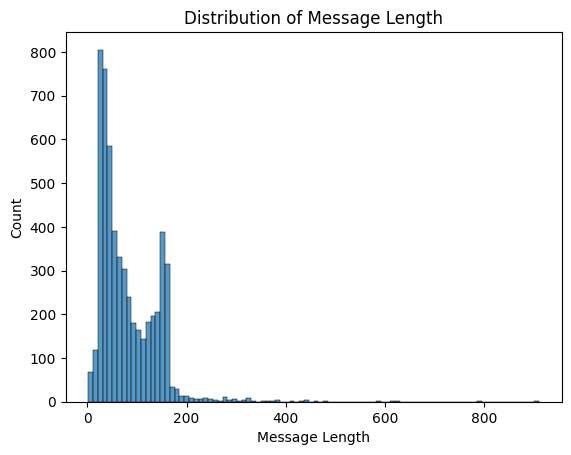

In [20]:
plt.Figure(figsize=(10,5))
sns.histplot(df['message_length'])
plt.title('Distribution of Message Length')
plt.xlabel('Message Length')
plt.ylabel('Count')
plt.show()

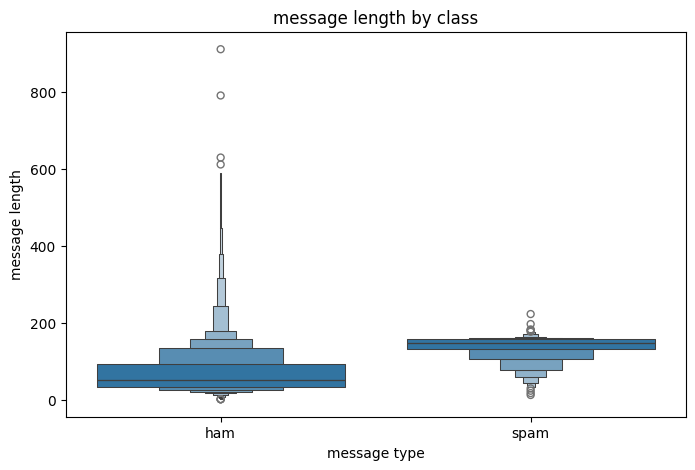

In [21]:
plt.figure(figsize=(8,5))

sns.boxenplot(df, x='label', y='message_length')
plt.title('message length by class')
plt.xlabel('message type')
plt.ylabel('message length')

plt.show()